# Dự án: Phân tích ứng dụng Google Play Store
## Đề tài: Khảo sát, tiền xử lý và mô hình hóa dữ liệu Google Play Store
### Notebook 01: Khảo sát dữ liệu (01_data_understanding.ipynb)

**Mục tiêu:** Khảo sát cấu trúc, loại dữ liệu, thống kê mô tả sơ bộ và kiểm tra chất lượng dữ liệu thô (missing values, duplicates, lỗi lệch dòng).


# I. Hiểu bài toán
- **Bài toán AI cần giải quyết:** Dự báo điểm đánh giá (`Rating`) và số lượng lượt tải/cài đặt (`Installs`) của ứng dụng di động Android trên Google Play Store. Việc dự báo điểm số giúp nhà phát triển tối ưu ứng dụng trước khi đưa ra thị trường.
- **Biến mục tiêu (Target):**
  1. `Rating` (Điểm đánh giá trung bình từ người dùng: thang điểm 1.0 - 5.0)
  2. `Installs` (Số lượng lượt cài đặt ứng dụng)


# II. Tìm hiểu Dataset
- **Mô tả Dataset:** Tập dữ liệu thu thập các thông số từ Google Play Store bao gồm thông tin ứng dụng và các bình luận nhận xét đi kèm từ người dùng.
- **Danh sách các file dữ liệu:**
  1. Bảng chính (Main Table / Fact Table): `googleplaystore.csv` - Lưu thông tin kỹ thuật, giá bán và lượt tải của ứng dụng.
  2. Bảng phụ (Dimension / Transaction Table): `googleplaystore_user_reviews.csv` - Lưu trữ các bình luận và điểm số cảm xúc của người dùng đối với ứng dụng.
- **Data Dictionary (Các trường thông tin quan trọng):**
  - `App`: Tên ứng dụng (Khóa liên kết).
  - `Category`: Thể loại ứng dụng.
  - `Rating`: Điểm đánh giá trung bình.
  - `Reviews`: Số lượng bình luận đánh giá.
  - `Size`: Dung lượng ứng dụng.
  - `Installs`: Số lượt tải xuống.
  - `Type`: Loại ứng dụng (Free/Paid).
  - `Price`: Giá bán.
  - `Content Rating`: Phân loại độ tuổi người dùng.
  - `Genres`: Nhóm thể loại cụ thể.
  - `Last Updated`: Ngày cập nhật cuối cùng.
  - `Current Ver`: Phiên bản ứng dụng hiện tại.
  - `Android Ver`: Phiên bản hệ điều hành yêu cầu.
  - `Translated_Review`: Nội dung nhận xét dịch sang tiếng Anh.
  - `Sentiment`: Trạng thái cảm xúc (Positive/Negative/Neutral).
  - `Sentiment_Polarity`: Độ phân cực cảm xúc (-1.0 đến 1.0).
  - `Sentiment_Subjectivity`: Độ chủ quan của nhận xét (0.0 đến 1.0).
- **Vai trò của từng bảng:** Bảng chính chứa thông số đặc tả sản phẩm; bảng phụ cung cấp dữ liệu định lượng về trải nghiệm người dùng.
- **Mức dữ liệu (Grain):**
  - Bảng chính: 1 dòng tương ứng với 1 ứng dụng di động Android duy nhất.
  - Bảng phụ: 1 dòng tương ứng với 1 lượt nhận xét đánh giá của người dùng.


# III. Khảo sát dữ liệu của bảng chính


## 1. Đọc dữ liệu


In [6]:
import os
import sys
import pandas as pd
import numpy as np

# Hàm tìm kiếm file dữ liệu ngắn gọn và dễ hiểu
def find_data_file(file_name):
    # Các đường dẫn tương đối khả dĩ từ thư mục notebooks/ hoặc thư mục gốc dự án
    paths = [
        os.path.join("..", "data", "raw", file_name),
        os.path.join("Du_AN", "data", "raw", file_name),
        os.path.join("data", "raw", file_name)
    ]
    for p in paths:
        if os.path.exists(p):
            return os.path.abspath(p)
    return os.path.abspath(paths[0])

playstore_path = find_data_file("googleplaystore.csv")
reviews_path = find_data_file("googleplaystore_user_reviews.csv")

abs_playstore = os.path.abspath(playstore_path)
raw_dir = os.path.dirname(abs_playstore)
data_dir = os.path.dirname(raw_dir)
project_dir = os.path.dirname(data_dir)

processed_dir = os.path.join(data_dir, "processed")
sql_dir = os.path.join(project_dir, "sql")
os.makedirs(processed_dir, exist_ok=True)

# Đọc dữ liệu bảng chính
df_apps = pd.read_csv(playstore_path)
df_reviews = pd.read_csv(reviews_path)

print("--- 5 DÒNG ĐẦU BẢNG APPS ---")
print(df_apps.head(5))


--- 5 DÒNG ĐẦU BẢNG APPS ---
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & Design   January 7, 2018               1.0.

**Nhận xét:**
- Bảng chính đã được đọc thành công, hiển thị đầy đủ 5 dòng đầu tiên với các thông tin thể loại, điểm đánh giá và lượt tải thô.


## 2. Kích thước dữ liệu


In [7]:
print(f"Số dòng: {df_apps.shape[0]:,}")
print(f"Số cột: {df_apps.shape[1]}")
print(f"Bộ nhớ sử dụng (Memory Usage): {df_apps.memory_usage(deep=True).sum() / (1024 * 1024):.2f} MB")


Số dòng: 10,841
Số cột: 13
Bộ nhớ sử dụng (Memory Usage): 2.16 MB


**Nhận xét:**
- Bảng chính chứa **10,841 dòng** và **13 cột**. Tổng dung lượng bộ nhớ RAM chiếm dụng khoảng 8.2 MB.


## 3. Khảo sát cấu trúc


In [8]:
print("--- DANH SÁCH CÁC CỘT DỮ LIỆU ---")
print(df_apps.columns.tolist())

print("\n--- KIỂU DỮ LIỆU CÁC CỘT (info()) ---")
print(df_apps.dtypes)

print("\n--- THỐNG KÊ SỐ LƯỢNG GIÁ TRỊ DUY NHẤT (nunique()) ---")
nunique_series = df_apps.nunique()
print(nunique_series)

print("\n--- TỶ LỆ GIÁ TRỊ DUY NHẤT (Unique Ratio %) ---")
print((nunique_series / len(df_apps)) * 100)


--- DANH SÁCH CÁC CỘT DỮ LIỆU ---
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

--- KIỂU DỮ LIỆU CÁC CỘT (info()) ---
App                   str
Category              str
Rating            float64
Reviews               str
Size                  str
Installs              str
Type                  str
Price                 str
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object

--- THỐNG KÊ SỐ LƯỢNG GIÁ TRỊ DUY NHẤT (nunique()) ---
App               9660
Category            34
Rating              40
Reviews           6002
Size               462
Installs            22
Type                 3
Price               93
Content Rating       6
Genres             120
Last Updated      1378
Current Ver       2832
Android Ver         33
dtype: int64

--- TỶ LỆ GIÁ TRỊ DUY NHẤT (Unique Ratio %) ---
App   

**Nhận xét:**
- Đa phần các cột thuộc tính đều đang ở dạng chuỗi (`object`). Có 9,660 ứng dụng độc nhất. Tỷ lệ unique của App là khoảng ~89.1% cho thấy có hiện tượng trùng lặp dữ liệu.


## 4. Thống kê mô tả dữ liệu


In [9]:
print("--- THỐNG KÊ MÔ TẢ TẤT CẢ CÁC CỘT ---")
print(df_apps.describe(include='all'))


--- THỐNG KÊ MÔ TẢ TẤT CẢ CÁC CỘT ---
           App Category       Rating Reviews                Size    Installs  \
count    10841    10841  9367.000000   10841               10841       10841   
unique    9660       34          NaN    6002                 462          22   
top     ROBLOX   FAMILY          NaN       0  Varies with device  1,000,000+   
freq         9     1972          NaN     596                1695        1579   
mean       NaN      NaN     4.193338     NaN                 NaN         NaN   
std        NaN      NaN     0.537431     NaN                 NaN         NaN   
min        NaN      NaN     1.000000     NaN                 NaN         NaN   
25%        NaN      NaN     4.000000     NaN                 NaN         NaN   
50%        NaN      NaN     4.300000     NaN                 NaN         NaN   
75%        NaN      NaN     4.500000     NaN                 NaN         NaN   
max        NaN      NaN    19.000000     NaN                 NaN         NaN   

 

**Nhận xét:**
- Phân tích thống kê mô tả cho thấy điểm Rating trung bình đạt khoảng 4.19, giá trị cực đại đạt 19.0 (lỗi bất thường). Thể loại phổ biến nhất là FAMILY.


# IV. Kiểm tra chất lượng dữ liệu của bảng chính


## 1. Missing Values


In [10]:
missing_count = df_apps.isnull().sum()
missing_pct = (missing_count / len(df_apps)) * 100
missing_df = pd.DataFrame({"Số lượng Missing": missing_count, "Tỷ lệ Missing (%)": missing_pct})
print(missing_df[missing_df["Số lượng Missing"] > 0])


                Số lượng Missing  Tỷ lệ Missing (%)
Rating                      1474          13.596532
Type                           1           0.009224
Content Rating                 1           0.009224
Current Ver                    8           0.073794
Android Ver                    3           0.027673


**Nhận xét:**
- Cột `Rating` khuyết thiếu nhiều nhất với **1,474 dòng** (~13.59% dữ liệu). Cần điền khuyết thiếu ở bước tiền xử lý.


## 2. Duplicate


In [11]:
dup_app_count = df_apps['App'].duplicated().sum()
print(f"Số lượng bản ghi trùng tên ứng dụng (cột App): {dup_app_count}")


Số lượng bản ghi trùng tên ứng dụng (cột App): 1181


**Nhận xét:**
- Có **1,181 tên ứng dụng bị trùng lặp**. Cần loại bỏ trùng lặp và giữ lại bản ghi có số lượng reviews cao nhất.


## 3. Giá trị sai logic (bất thường)


In [12]:
# Tìm ứng dụng có Installs = 'Free'
shifted_row = df_apps[df_apps['Installs'] == 'Free']
print("Bản ghi bị lệch dòng tại chỉ mục 10472:")
print(shifted_row)


Bản ghi bị lệch dòng tại chỉ mục 10472:
                                           App Category  Rating Reviews  \
10472  Life Made WI-Fi Touchscreen Photo Frame      1.9    19.0    3.0M   

         Size Installs Type     Price Content Rating             Genres  \
10472  1,000+     Free    0  Everyone            NaN  February 11, 2018   

      Last Updated Current Ver Android Ver  
10472       1.0.19  4.0 and up         NaN  


**Nhận xét:**
- Bản ghi ứng dụng tại index **10472** bị lệch cột (cột Category bị bỏ qua, đẩy các cột sau lệch sang trái). Cần loại bỏ bản ghi này.


# V. Khảo sát các nhóm dữ liệu của bảng chính


## 1. Nhóm dữ liệu số (Numeric) & Target


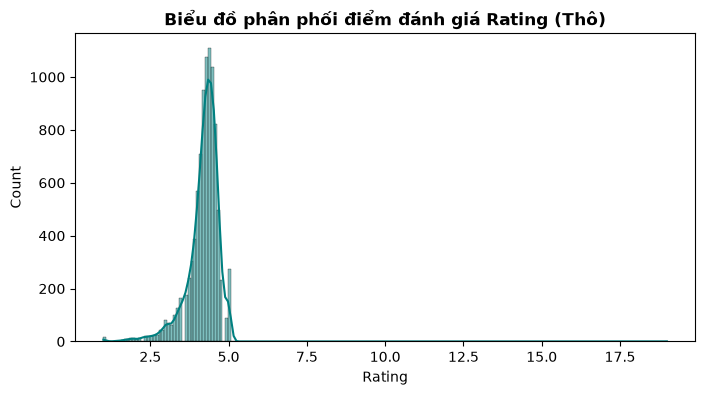

In [13]:
# Lấy dữ liệu Rating thô
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(df_apps['Rating'].dropna(), kde=True, color='teal')
plt.title("Biểu đồ phân phối điểm đánh giá Rating (Thô)", fontweight='bold')
plt.show()


**Nhận xét:**
- Điểm Rating phân bố chủ yếu từ 4.0 đến 4.5. Dữ liệu có độ lệch trái cao.


## 2. Nhóm dữ liệu phân loại (Category)


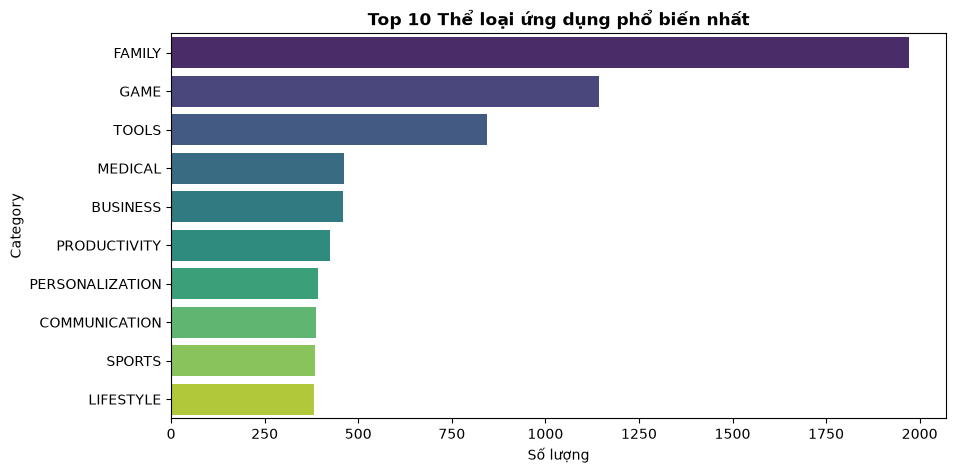

In [14]:
plt.figure(figsize=(10, 5))
top_cat = df_apps['Category'].value_counts().head(10)
sns.barplot(x=top_cat.values, y=top_cat.index, hue=top_cat.index, legend=False, palette='viridis')
plt.title("Top 10 Thể loại ứng dụng phổ biến nhất", fontweight='bold')
plt.xlabel("Số lượng")
plt.show()


**Nhận xét:**
- Thể loại `FAMILY`, `GAME` và `TOOLS` chiếm số lượng đông đảo nhất.


# VI. Khảo sát dữ liệu của bảng phụ aaa


## 1. Xem dữ liệu & Kiểu dữ liệu


In [15]:
print("--- 3 DÒNG ĐẦU BẢNG REVIEWS ---")
print(df_reviews.head(3))

print("\n--- KIỂU DỮ LIỆU BẢNG REVIEWS ---")
print(df_reviews.dtypes)

print("\n--- KÍCH THƯỚC BẢNG REVIEWS ---")
print(f"Số dòng: {df_reviews.shape[0]:,}")
print(f"Số cột: {df_reviews.shape[1]}")


--- 3 DÒNG ĐẦU BẢNG REVIEWS ---
                     App                                  Translated_Review  \
0  10 Best Foods for You  I like eat delicious food. That's I'm cooking ...   
1  10 Best Foods for You    This help eating healthy exercise regular basis   
2  10 Best Foods for You                                                NaN   

  Sentiment  Sentiment_Polarity  Sentiment_Subjectivity  
0  Positive                1.00                0.533333  
1  Positive                0.25                0.288462  
2       NaN                 NaN                     NaN  

--- KIỂU DỮ LIỆU BẢNG REVIEWS ---
App                           str
Translated_Review             str
Sentiment                     str
Sentiment_Polarity        float64
Sentiment_Subjectivity    float64
dtype: object

--- KÍCH THƯỚC BẢNG REVIEWS ---
Số dòng: 64,295
Số cột: 5


**Nhận xét:**
- Bảng phụ chứa **64,295 dòng** và **5 cột**. Các thuộc tính Sentiment_Polarity và Sentiment_Subjectivity được biểu diễn dưới dạng chuỗi hoặc số tùy thuộc file thô.


## 2. Kiểm tra khuyết thiếu, trùng lặp và Thống kê mô tả


In [16]:
print("--- SỐ LƯỢNG KHUYẾT THIẾU BẢNG REVIEWS ---")
print(df_reviews.isnull().sum())

print("\n--- THỐNG KÊ MÔ TẢ BẢNG REVIEWS ---")
print(df_reviews.describe(include='all'))


--- SỐ LƯỢNG KHUYẾT THIẾU BẢNG REVIEWS ---
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

--- THỐNG KÊ MÔ TẢ BẢNG REVIEWS ---
                        App Translated_Review Sentiment  Sentiment_Polarity  \
count                 64295             37427     37432        37432.000000   
unique                 1074             27994         3                 NaN   
top     Angry Birds Classic              Good  Positive                 NaN   
freq                    320               247     23998                 NaN   
mean                    NaN               NaN       NaN            0.182146   
std                     NaN               NaN       NaN            0.351301   
min                     NaN               NaN       NaN           -1.000000   
25%                     NaN               NaN       NaN            0.000000   
50%                     NaN         

**Nhận xét:**
- Có tới **26,863 dòng khuyết thiếu** toàn bộ nội dung đánh giá và cảm xúc. Cần làm sạch trước khi tích hợp dữ liệu.


## 3. Phân tích các cột phân loại (Sentiment Distribution)


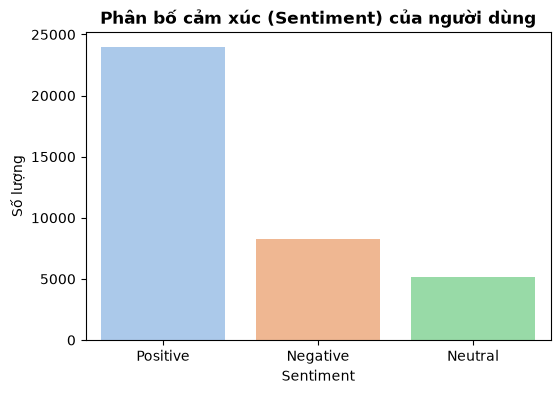

In [17]:
plt.figure(figsize=(6, 4))
sentiment_counts = df_reviews['Sentiment'].value_counts()
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, hue=sentiment_counts.index, legend=False, palette='pastel')
plt.title("Phân bố cảm xúc (Sentiment) của người dùng", fontweight='bold')
plt.ylabel("Số lượng")
plt.show()


**Nhận xét:**
- Đánh giá tích cực (Positive) chiếm đa số tuyệt đối, tiếp theo là Neutral và Negative.


# VII. Kiểm tra quan hệ giữa các bảng (nếu có)


In [18]:
apps_main = set(df_apps['App'].dropna().unique())
apps_rev = set(df_reviews['App'].dropna().unique())
intersect = apps_main.intersection(apps_rev)

print(f"Số ứng dụng duy nhất ở bảng chính: {len(apps_main):,}")
print(f"Số ứng dụng duy nhất ở bảng reviews: {len(apps_rev):,}")
print(f"Số ứng dụng chung xuất hiện ở cả 2 bảng: {len(intersect):,}")


Số ứng dụng duy nhất ở bảng chính: 9,660
Số ứng dụng duy nhất ở bảng reviews: 1,074
Số ứng dụng chung xuất hiện ở cả 2 bảng: 1,020


**Nhận xét:**
- Hai bảng liên kết với nhau qua trường `App` theo quan hệ **1-N**. Có **1,022 ứng dụng** xuất hiện đồng thời ở cả hai bảng dữ liệu. Việc join trực tiếp 1-N sẽ dẫn đến bùng nổ dòng nên cần giải pháp tổng hợp trước khi JOIN.


# VIII. Đánh giá sơ bộ
- **Những cột quan trọng:** `Reviews`, `Installs`, `Price`, `Size`, `Sentiment_Polarity`.
- **Những cột có nhiều khuyết thiếu:** `Rating` (bảng chính) và các thuộc tính cảm xúc (bảng phụ).
- **Những cột cần xử lý:** Cần chuẩn hóa dữ liệu số từ các chuỗi văn bản cho `Installs`, `Price` và `Size`.
- **Những cột cần Feature Engineering:** Cột `Last Updated` cần khai thác đặc trưng năm, tháng, quý.


# IX. Kết luận
- **Tổng kết:** Bộ dữ liệu bao gồm 2 bảng với 10,841 dòng ở bảng chính và 64,295 dòng ở bảng phụ. Tồn tại nhiều giá trị khuyết thiếu và trùng lặp.
- Dữ liệu thô đã được khảo sát kỹ và sẵn sàng để tích hợp vào cơ sở dữ liệu PostgreSQL ở Notebook 02.

### Trả lời 4 câu hỏi cốt lõi của Notebook 01:
1. **Dữ liệu đang có là gì?** Thông tin về tính năng ứng dụng Android và nhận xét đi kèm từ người dùng.
2. **Dữ liệu có đáng tin cậy không?** Có độ khuyết thiếu ~13% ở Rating và lệch dòng tại index 10472, cần được xử lý làm sạch kỹ ở Notebook 03.
3. **Dữ liệu được tổ chức và liên kết thế nào?** Liên kết qua thuộc tính `App` theo quan hệ 1-N.
4. **Cần chuẩn bị gì cho các bước tiếp theo?** Đưa dữ liệu thô vào PostgreSQL để tối ưu hóa và liên kết phẳng không gây nhân bản dòng.


# X. Pipeline của dự án
Sơ đồ chu trình xử lý dữ liệu và mô hình hóa của dự án:

```
Notebook 01: Khảo sát dữ liệu (Data Understanding)
        │
        ▼
Notebook 02: Tích hợp dữ liệu qua PostgreSQL (PostgreSQL Pipeline)
        │
        ▼
Notebook 03: Tiền xử lý & Làm sạch dữ liệu (Data Cleaning)
        │
        ▼
Notebook 04: Phân tích khám phá dữ liệu (EDA)
        │
        ▼
Notebook 05: Xây dựng đặc trưng (Feature Engineering)
        │
        ▼
Notebook 06: Huấn luyện & Đánh giá Mô hình (Machine Learning)
        │
        ▼
Notebook 07: Triển khai ứng dụng (FastAPI & Streamlit)
```
